> Tensorflow Documentation - https://www.tensorflow.org/api_docs/python/

UV is An extremely fast Python package and project manager, faster 10-100x time than pip.
Installing UV, setting Up Virtual Environment and downloading depending dependencies.

```sh
pip install uv
uv venv --python 3.10
uv pip install -r requirements.txt
```

In [1]:
import tensorflow as tf # models
import pandas as pd # reading & processing
import seaborn as sns #visualization
from tensorflow.keras.layers import Normalization, Dense, InputLayer
from tensorflow.keras.losses import MeanSquaredError, MeanAbsoluteError, Huber


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\Ishaan Rastogi\AppData\Roaming\uv\python\cpython-3.10-windows-x86_64-none\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\Ishaan Rastogi\AppData\Roaming\uv\python\cpython-3.10-windows-x86_64-none\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "c:\Users\Ishaan Rastogi\Desktop\DLforCV\.venv\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\Ishaan Rastogi\Desktop

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\Ishaan Rastogi\AppData\Roaming\uv\python\cpython-3.10-windows-x86_64-none\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\Ishaan Rastogi\AppData\Roaming\uv\python\cpython-3.10-windows-x86_64-none\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "c:\Users\Ishaan Rastogi\Desktop\DLforCV\.venv\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\Ishaan Rastogi\Desktop

AttributeError: _ARRAY_API not found

ImportError: numpy.core._multiarray_umath failed to import

ImportError: numpy.core.umath failed to import

TypeError: Unable to convert function return value to a Python type! The signature was
	() -> handle

# Building Neural Networks [Car Price Prediction]

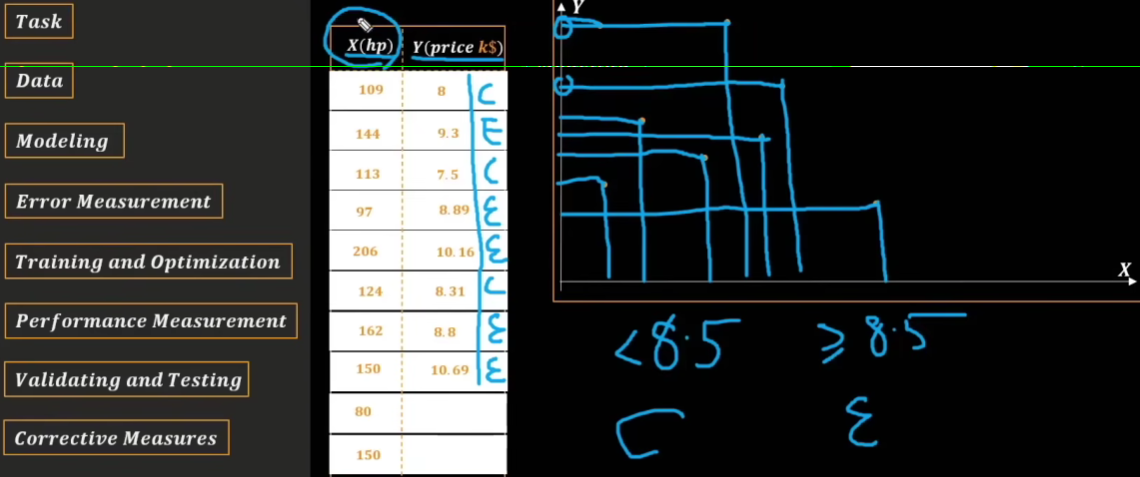
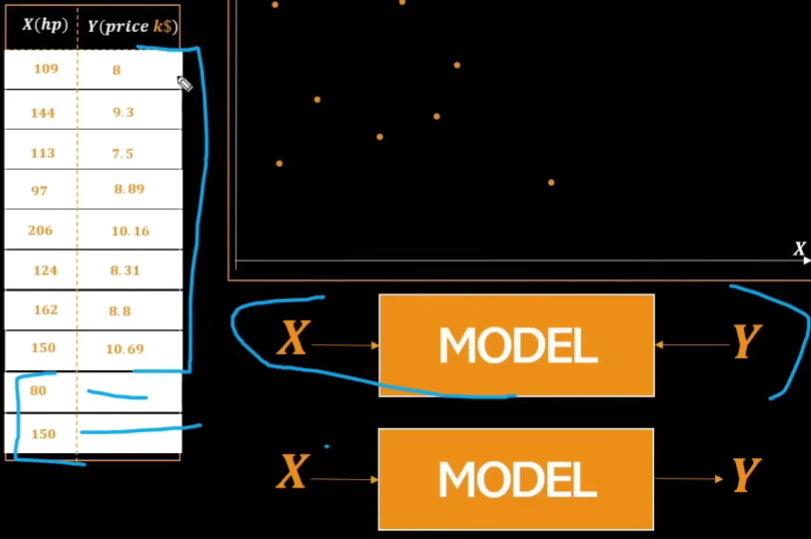
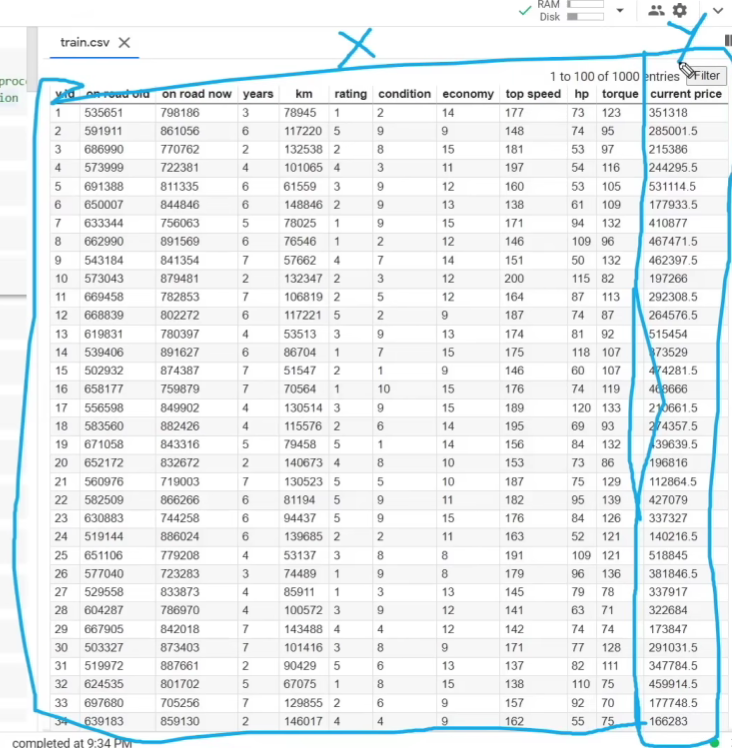

## Data Preparation

In [ ]:
data = pd.read_csv("train.csv", sep = ",")

In [ ]:
data.head()

In [ ]:
data.shape

seaborn documentation - https://seaborn.pydata.org/generated/seaborn.pairplot.html

In [ ]:
sns.pairplot(data[['v.id','on road old','on road now','years','km','rating','condition','economy','top speed','hp','torque','current price']], diag_kind='kde')

In [ ]:
tensor_data = tf.constant(data)
tensor_data = tf.cast(tensor_data, tf.float32)
print(tensor_data)

In [ ]:
# Randomly shuffle the data to remove any bias
tensor_data = tf.random.shuffle(tensor_data)
print(tensor_data[:5])

In [ ]:
X = tensor_data[:, 3:-1]
X.shape

In [ ]:
X[:5]

In [ ]:
y = tensor_data[:, -1]
y = tf.expand_dims(y, axis = -1)
y[:5]

In [ ]:
'''
tf.keras.layers.Normalization - A preprocessing layer that normalizes continuous features.

Applies formula of (input - mean) / Standard Deviation
where S.D. = square root of variance
'''

x_normalized = tf.constant([[3,4,5,6,7], [4,5,6,7,8]])
normalizer = Normalization(axis = -1, mean = 5, variance = 4) # Just taking as example, the parameters
normalizer(x_normalized) # Using axis = -1, means we have to use the innermost dimension which has these 5 features each, rather than axis = 0 having batch size = 2.

In [ ]:
# Rather than manually setting up mean and variance, tensorflow can smartly calculate on its own

x_normalized = tf.constant([[3,4,5,6,7], [4,5,6,7,8]])
normalizer = Normalization()
normalizer.adapt(x_normalized) # During adapt(), the layer will compute a mean and variance separately for each position in each axis specified by the axis argument.
normalizer(x_normalized)

# Eg- For Column 1, mean is 3.5, for next column 4.5 and so on the mean and variance will be calcuted differently for each column

In [ ]:
x_normalized = tf.constant([[3,4,5,6,7], [4,5,6,7,8], [32,1,56,3,5]])
normalizer.adapt(x_normalized)
normalizer(x_normalized)

In [ ]:
normalizer = Normalization()
normalizer.adapt(X)
normalizer(X)[:5]

In [ ]:
X[:5]

## Linear Regression Model

In [ ]:
# tf.keras.Sequential - Sequential groups a linear stack of layers into a Model.
# tf.keras.layers.Dense - Just your regular densely-connected NN layer.

model = tf.keras.Sequential([
    InputLayer(shape = (8,)), # where batch = 8
    normalizer,
    Dense(1) # Dense layer
])
model.build((None, 8)) # 8 weights + 1 bias = 0 trainable params
model.summary()

In [ ]:
tf.keras.utils.plot_model(model, to_file = "model.png", show_shapes = True)

## Error Sanctioning

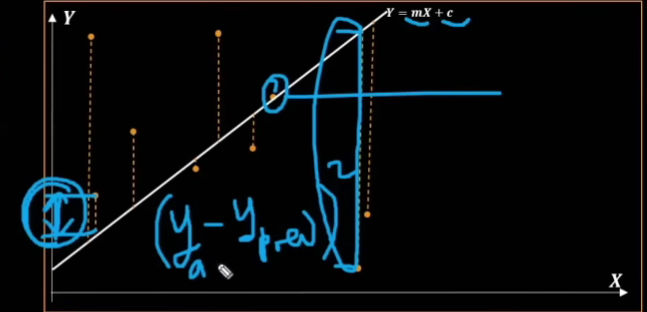

Absolute Error is preferred over MSE when outlier is like this: <br>
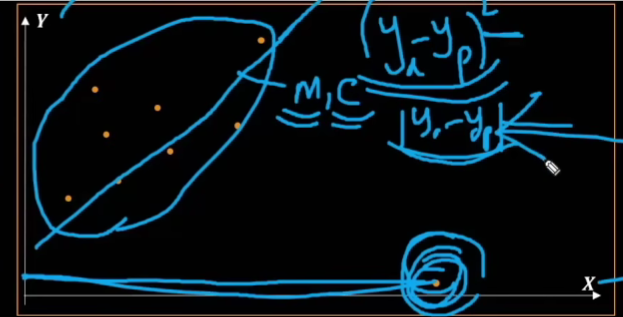

MSE, MAE, Hubber Loss: <br>
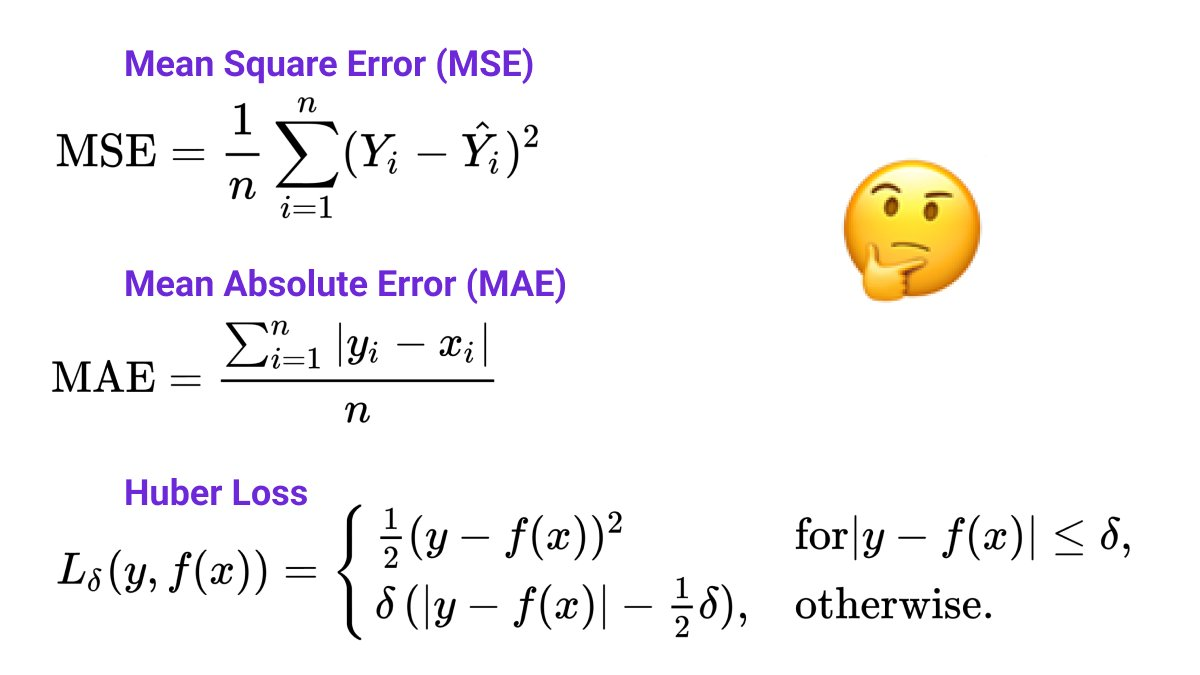

In [ ]:
# tf.keras.losses.MeanSquaredError - Computes the mean of squares of errors between labels and predictions.

model.compile(loss = MeanSquaredError())

In [ ]:
# tf.keras.losses.MeanAbsoluteError - Computes the mean of absolute difference between labels and predictions.

model.compile(loss = MeanAbsoluteError())

In [ ]:
# tf.keras.losses.Huber - Computes the Huber loss between y_true & y_pred.

model.compile(loss = Huber())

## Training & Optimization

- Gradient Descent Formula - `W = Wp - (LR) * dL/dWp` where
    - W = Weight after learning 
    - Wp = Weight before learning
    - LR - Learning Rate ( How big a learning step is)
    - dL/dWp (The Gradient) - derivate of Loss L with respect to previous weight Wp
    - Loss L is a measure of how wrong the model's predictions are compared to the actual correct one

- Learning Rate can neither be too low nor too high

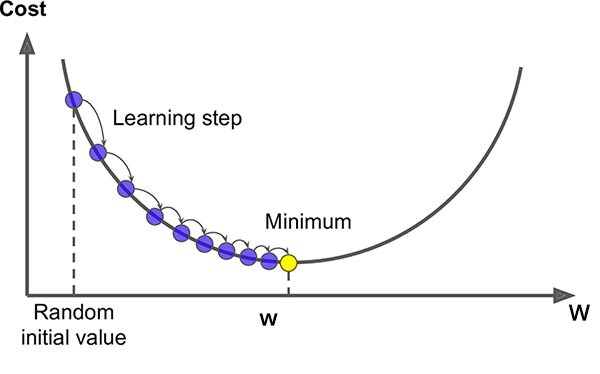

- We can use this formula like this example. y = mx + c where
    - m = 0 - 0.1 * dL/dm
    - c = 2 - 0.1 * dL/dc

In [ ]:
# an epoch - one complete pass of the entire training dataset through the model.
# verbose - determines how much information is displayed in the console during model training or evaluation.

model.fit(X,y, epochs = 100, verbose = 1)